
=== Player Retention & Drop-Off Summary ===


,level_num,completed,continued,dropped,retention_%,drop_%
0,1,160,131,25,81.9,15.6
1,2,80,71,9,88.8,11.2
2,3,48,0,0,0.0,0.0



Total players who completed the full game (Level 3): 48


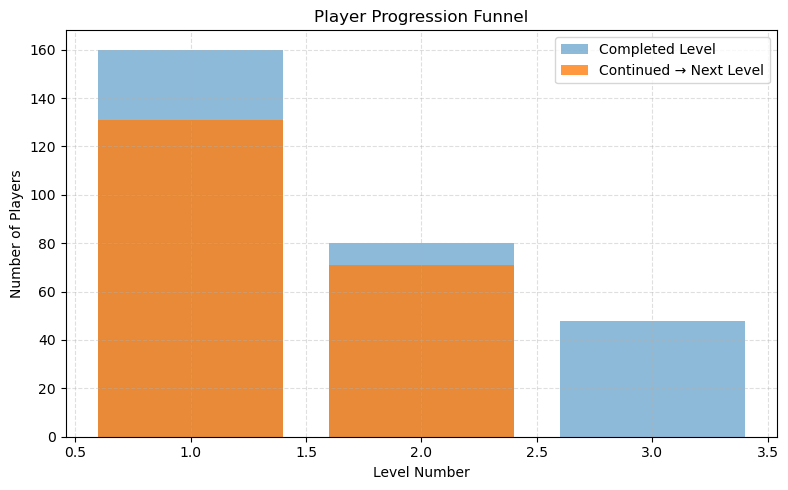

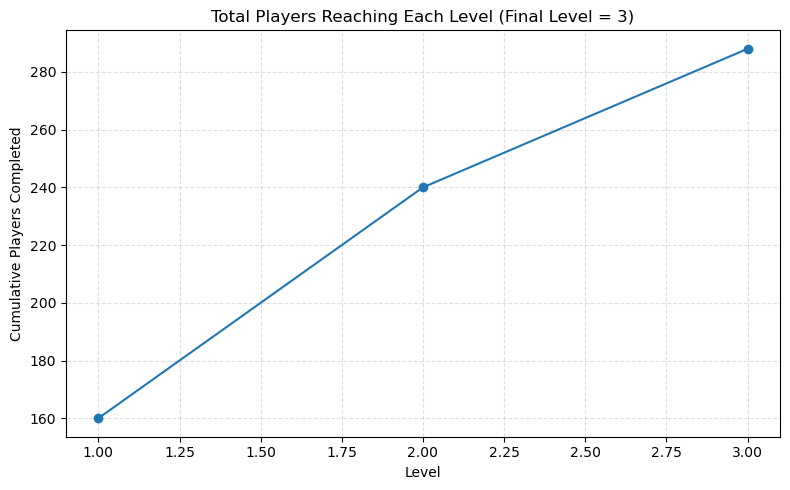

Saved: metric3_retention_completion_summary.csv


In [1]:
# Player Retention, Drop-Off, and Game Completion Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("metric1.csv")
df.columns = [c.strip() for c in df.columns]
df["event_time"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)

def level_to_int(x):
    if pd.isna(x): return np.nan
    s = str(x)
    d = ''.join(ch for ch in s if ch.isdigit())
    return int(d) if d else np.nan

df["level_num"] = df["level"].apply(level_to_int).astype("Int64")

success = (
    df[(df["eventType"] == "RunEnd") & (df["result"] == "success")]
    .sort_values("event_time")
    .groupby(["sessionId", "level_num"], as_index=False)
    .agg(success_time=("event_time", "first"))
)

min_event_time = (
    df.groupby(["sessionId", "level_num"], as_index=False)
      .agg(first_seen=("event_time", "min"))
)

merged = success.copy()
merged["next_level"] = merged["level_num"] + 1

merged = merged.merge(
    min_event_time.rename(columns={"level_num": "next_level", "first_seen": "next_seen"}),
    on=["sessionId", "next_level"],
    how="left"
)

merged["continued_to_next"] = (
    merged["next_seen"].notna() & (merged["next_seen"] > merged["success_time"])
)

last_level = df.groupby("sessionId", as_index=False)["level_num"].max()
last_level.rename(columns={"level_num": "last_level_reached"}, inplace=True)
merged = merged.merge(last_level, on="sessionId", how="left")

FINAL_LEVEL = 3
merged["dropped_after_this_level"] = (
    (merged["level_num"] < FINAL_LEVEL)
    & (merged["level_num"] == merged["last_level_reached"])
)

summary = (
    merged.groupby("level_num", as_index=False)
    .agg(
        completed=("sessionId", "nunique"),
        continued=("continued_to_next", "sum"),
        dropped=("dropped_after_this_level", "sum")
    )
)
summary["retention_%"] = (summary["continued"] / summary["completed"] * 100).round(1)
summary["drop_%"] = (summary["dropped"] / summary["completed"] * 100).round(1)
summary = summary.sort_values("level_num").reset_index(drop=True)

completed_game = success.loc[success["level_num"] == FINAL_LEVEL, "sessionId"].nunique()

print("\n=== Player Retention & Drop-Off Summary ===")
display(summary)
print(f"\nTotal players who completed the full game (Level {FINAL_LEVEL}): {completed_game}")

plt.figure(figsize=(8,5))
plt.bar(summary["level_num"], summary["completed"], alpha=0.5, label="Completed Level")
plt.bar(summary["level_num"], summary["continued"], alpha=0.8, label="Continued → Next Level")
plt.xlabel("Level Number")
plt.ylabel("Number of Players")
plt.title("Player Progression Funnel")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

summary["cumulative_completers"] = summary["completed"].cumsum()

plt.figure(figsize=(8,5))
plt.plot(summary["level_num"], summary["cumulative_completers"], marker="o")
plt.xlabel("Level")
plt.ylabel("Cumulative Players Completed")
plt.title(f"Total Players Reaching Each Level (Final Level = {FINAL_LEVEL})")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

summary.to_csv("metric3_retention_completion_summary.csv", index=False)
print("Saved: metric3_retention_completion_summary.csv")


=== Counts (from players who started at Level 1) ===
Started at Level 1: 130
Quit at Level 1: 43
L1 → L2: 87
Quit at Level 2: 40
L2 → L3: 47
Completed Level 3: 34


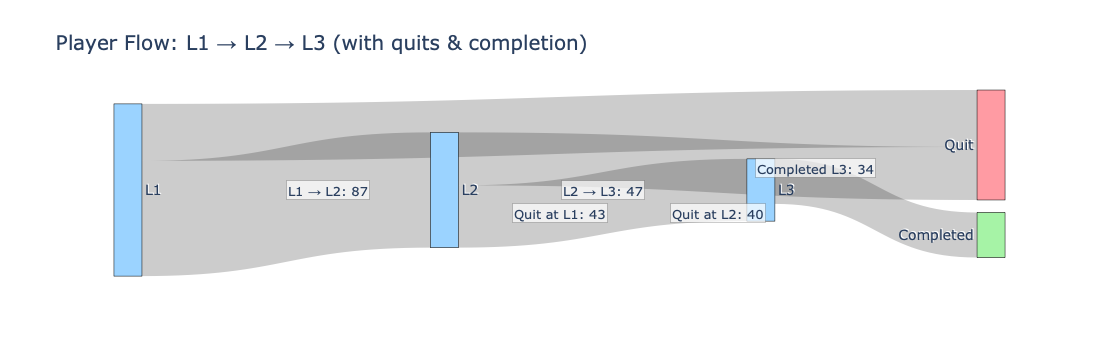

In [12]:
# L1 -> L2, Quit at L1, L2 -> L3, Quit at L2, Completed L3
import pandas as pd
from collections import defaultdict
import plotly.graph_objects as go

df = pd.read_csv("metric1.csv")
df.columns = [c.strip() for c in df.columns]
if "ts" in df.columns:
    df["event_time"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
else:
    df["event_time"] = pd.to_datetime(df["Timestamp"], errors="coerce", utc=True)

def level_to_int(x):
    s = str(x)
    digits = "".join(ch for ch in s if ch.isdigit())
    return int(digits) if digits else None

df["level_num"] = df["level"].apply(level_to_int)
df = df.dropna(subset=["level_num"]).copy()
df["level_num"] = df["level_num"].astype(int)

reached = (df.sort_values("event_time")
             .groupby(["sessionId", "level_num"], as_index=False)
             .agg(first_seen=("event_time", "first")))

reached_L1 = set(reached.loc[reached["level_num"] == 1, "sessionId"])
reached_L2 = set(reached.loc[reached["level_num"] == 2, "sessionId"])
reached_L3 = set(reached.loc[reached["level_num"] == 3, "sessionId"])

reached_times = {(r.sessionId, r.level_num): r.first_seen for _, r in reached.iterrows()}

def went(from_level, to_level, sess_set_from, sess_set_to):
    cnt = 0
    for s in (sess_set_from & sess_set_to):
        if reached_times[(s, to_level)] > reached_times[(s, from_level)]:
            cnt += 1
    return cnt

L1_to_L2 = went(1, 2, reached_L1, reached_L2)
L2_to_L3 = went(2, 3, reached_L2, reached_L3)

completed_L3_sessions = set(
    df[(df["level_num"] == 3) & (df["eventType"] == "RunEnd") & (df["result"].str.lower() == "success")]["sessionId"]
)
completed_L3 = len(completed_L3_sessions)

starters = len(reached_L1)
started_L2 = len(reached_L2)
quit_at_L1 = starters - L1_to_L2
quit_at_L2 = started_L2 - L2_to_L3

print("=== Counts (from players who started at Level 1) ===")
print(f"Started at Level 1: {starters}")
print(f"Quit at Level 1: {quit_at_L1}")
print(f"L1 → L2: {L1_to_L2}")
print(f"Quit at Level 2: {quit_at_L2}")
print(f"L2 → L3: {L2_to_L3}")
print(f"Completed Level 3: {completed_L3}")

labels = ["L1", "L2", "L3", "Quit", "Completed"]

links = [
    ("L1", "Quit", quit_at_L1,  "Quit at L1"),
    ("L1", "L2",   L1_to_L2,    "L1 → L2"),
    ("L2", "Quit", quit_at_L2,  "Quit at L2"),
    ("L2", "L3",   L2_to_L3,    "L2 → L3"),
    ("L3", "Completed", completed_L3, "Completed L3"),
]

idx = {lab: i for i, lab in enumerate(labels)}
source = [idx[a] for a, b, v, t in links]
target = [idx[b] for a, b, v, t in links]
value  = [int(v) for a, b, v, t in links]
text   = [t for a, b, v, t in links]

node_x = {
    "L1": 0.05, "L2": 0.38, "L3": 0.71,
    "Quit": 0.95, "Completed": 0.95
}
node_y = {
    "L1": 0.5, "L2": 0.5, "L3": 0.5,
    "Quit": 0.25, "Completed": 0.75
}

node = dict(
    pad=25, thickness=28,
    line=dict(color="black", width=0.5),
    label=labels,
    color=["#9bd3ff", "#9bd3ff", "#9bd3ff", "#ff9ba3", "#a6f3a6"],
    x=[node_x[l] for l in labels],
    y=[node_y[l] for l in labels]
)

link = dict(
    source=source, target=target, value=value,
    hoverlabel=dict(bgcolor="white"),
    hovertemplate="%{value} — %{customdata}<extra></extra>",
    customdata=text
)

fig = go.Figure(data=[go.Sankey(node=node, link=link, arrangement="fixed")])
fig.update_layout(title_text="Player Flow: L1 → L2 → L3 (with quits & completion)", font_size=14)

annotations = []
for (a, b, v, t), s_idx, t_idx in zip(links, source, target):
    if v == 0:
        continue
    ax, ay = node_x[labels[s_idx]], node_y[labels[s_idx]]
    bx, by = node_x[labels[t_idx]], node_y[labels[t_idx]]
    mx, my = (ax + bx) / 2, (ay + by) / 2
    annotations.append(dict(
        x=mx, y=my, xref="paper", yref="paper",
        text=f"{t}: {v}",
        showarrow=False,
        font=dict(size=13),
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        align="center",
    ))

fig.update_layout(annotations=annotations)
fig.show()
